In [2]:
'''
This script analyzes gaits of a certain range from the test trial:
- duty factor
- phase difference matrix
- synchronization matrix
'''


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
# from common.normalized_env_66k import CoppeliaSimEnv
from common.normalized_env_66k_legloss import CoppeliaSimEnv
# from common.normalized_env_66k_RM_error import CoppeliaSimEnv
import os

# ======== Parameters (modify these as needed) ========= #
ENV_ID = "Medauroidea_66k_aug3c_legloss"
ALGO = "airl_logit_vx"
FILENAME = "20251103-1924" 
STEP_NUM = "840000"  
EPISODE = 1 # 
start = 70 # 
end = 120 #
fig_length = 4
fig_width = 2

STATES_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_states.csv"
ACTIONS_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_actions.csv"
VEL_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_velocities.csv"
FOOT_TRAJ_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_foot_trajs.csv"
'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
# RH_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_RH_joints.csv"

os.makedirs(f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}/", exist_ok=True)
SAVE_PATH = f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}"

# ======== Read Data ======== #
states = pd.read_csv(STATES_PATH, header=None, index_col=None)
actions = pd.read_csv(ACTIONS_PATH, header=None, index_col=None)
'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
actions.columns = [
                                    'LF_ThC', 'LF_CTr', 'LF_FTi', 
                                    'LM_ThC', 'LM_CTr', 'LM_FTi', 
                                    'LH_ThC', 'LH_CTr', 'LH_FTi',
                                    'RF_ThC', 'RF_CTr', 'RF_FTi', 
                                    # 'RM_ThC', 'RM_CTr', 'RM_FTi', 
                                    'RH_ThC', 'RH_CTr', 'RH_FTi'
                                    ]
velocities = pd.read_csv(VEL_PATH, header=None, index_col=None)
foot_trajs = pd.read_csv(FOOT_TRAJ_PATH, header=None, index_col=None)

'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
# rh = pd.read_csv(RH_PATH, header=None, index_col=None)
# rh.columns = ['RH_ThC', 'RH_CTr', 'RH_FTi']

# ======== Denormalize Data ======== #
env = CoppeliaSimEnv(simulation = False)
states = pd.DataFrame(env.denormalize_observation(states))
actions = env.denormalize_action(actions)

'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
states.columns = [
                #   'body_x', 'body_y',
                  'body_z', 
                  'body_roll', 'body_pitch', 'body_yaw', 
                  'LF_ThC', 'LF_CTr', 'LF_FTi', 
                  'LM_ThC', 'LM_CTr', 'LM_FTi', 
                  'LH_ThC', 'LH_CTr', 'LH_FTi',
                  'RF_ThC', 'RF_CTr', 'RF_FTi', 
                  'RM_ThC', 'RM_CTr', 'RM_FTi', 
                  'RH_ThC', 'RH_CTr', 'RH_FTi',
                  'force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH',
                #   'foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH',
                #   'contact_FL', 'contact_ML', 'contact_HL', 'contact_FR', 'contact_MR', 'contact_HR'
                  ]

'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
# states['RH_ThC'] = rh['RH_ThC']
# states['RH_CTr'] = rh['RH_CTr']
# states['RH_FTi'] = rh['RH_FTi']

forces = states[['force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH']].copy()

# ======== Gait Analysis ======== #
LEG_ORDER = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']

def _find_touchdowns(binary_array: np.ndarray):
    # Return the indices of 0->1 transitions (touchdowns) in a binary array
    b = np.asarray(binary_array).astype(int)
    td = (b[1:] == 1) & (b[:-1] == 0)
    return np.where(td)[0] + 1

def _cycles_and_duty(contact_1d: np.ndarray):
    # Divide gait cycles based on adjacent touchdowns, and compute duty factor within each cycle.
    td_idx = _find_touchdowns(contact_1d)
    cycles, duty = [], []
    if len(td_idx) < 2:
        return cycles, duty
    for i in range(len(td_idx) - 1):
        a, b = td_idx[i], td_idx[i + 1]
        if b - a <= 1:
            continue
        cyc_mask = contact_1d[a:b]
        cycles.append((a, b))
        duty.append(float(cyc_mask.mean()))
    return cycles, duty

def _leg_phase_series(contact_1d: np.ndarray):
    # For each touchdown->touchdown cycle, linearly interpolate phase from 0 to 1 (excluding endpoint 1), NaN elsewhere.
    n = len(contact_1d)
    td = _find_touchdowns(contact_1d)
    phase = np.full(n, np.nan, dtype=float)
    if len(td) < 2:
        return phase
    for i in range(len(td) - 1):
        a, b = td[i], td[i + 1]
        L = b - a
        if L > 0:
            phase[a:b] = np.linspace(0.0, 1.0, L, endpoint=False)
    return phase

def _circ_mean_phase_diff(phase_a, phase_b):
    # Return circular mean of phase difference (0~1 cycle) and synchronization index R (0~1).
    mask = ~np.isnan(phase_a) & ~np.isnan(phase_b)
    if mask.sum() == 0:
        return np.nan, np.nan
    d = (phase_b[mask] - phase_a[mask]) % 1.0
    ang = 2 * np.pi * d
    C, S = np.cos(ang).mean(), np.sin(ang).mean()
    mean_ang = np.arctan2(S, C)
    mean_phase = (mean_ang / (2 * np.pi)) % 1.0
    R = float(np.sqrt(C**2 + S**2))
    return float(mean_phase), R

def gait_quant_from_foot_z(foot_trajs_df, forces, start, end, use_foot_trajs=True, save_prefix="z"):
    '''
    Using "foot z < z_threshold" as the contact rule, compute and output:
        - Gait raster plot (filled=stance)
        - Duty Factor bar plot per leg (averaged over cycles)
        - Phase difference heatmap (0~1 cycle)
        - Synchronization index heatmap (R∈[0,1])
        - Tripod Index (proportion of time either tripod is in stance)
        - duty_factor_summary.csv / phase_diff_matrix.csv / sync_index_matrix.csv / tripod_index.txt
    '''
    # 1) Select range and binarize contact
    # foot_trajs_df: pd.DataFrame, forces: pd.DataFrame
    if use_foot_trajs:
        threshold = 0.02
        ft = foot_trajs_df.iloc[:, :6].to_numpy()  # (T, 6)
        ft = ft[start:end]                          # (T', 6)
        contacts = (ft < threshold).astype(int)   # (T', 6); 1=stance
    else:
        threshold = 0.27
        fc = forces.to_numpy()                      # (T, 6)
        fc = fc[start:end]                          # (T', 6)
        contacts = (fc > threshold).astype(int)    # (T', 6); 1=stance

    # 2) Gait Raster Plot
    plt.figure(figsize=(fig_length, fig_width))
    T = contacts.shape[0]
    for i in range(6):
        in_seg = False
        seg_start = 0
        for t in range(T):
            if contacts[t, i] == 1 and not in_seg:
                in_seg = True; seg_start = t
            if (contacts[t, i] == 0 or t == T - 1) and in_seg:
                seg_end = t if contacts[t, i] == 0 else t + 1
                plt.fill_between([seg_start, seg_end], i, i + 1, step="post")
                in_seg = False
    plt.yticks(np.arange(0.5, 6.5, 1), LEG_ORDER)
    plt.xlabel("Time (frames)")
    plt.title(f"Gait Raster")
    plt.tight_layout()
    plt.show()

    # 3) Duty Factor per Leg
    duty_means, duty_stds, n_cycles = [], [], []
    for i in range(6):
        _, dfs = _cycles_and_duty(contacts[:, i])
        dfs = np.array(dfs) if len(dfs) else np.array([])
        duty_means.append(dfs.mean() if dfs.size else np.nan)
        duty_stds.append(dfs.std(ddof=1) if dfs.size > 1 else np.nan)
        n_cycles.append(int(dfs.size))
    df_summary = pd.DataFrame({
        "leg": LEG_ORDER,
        "duty_mean": duty_means,
        "duty_std": duty_stds,
        "n_cycles": n_cycles,
    })

    plt.figure(figsize=(fig_length, fig_width))
    plt.bar(df_summary["leg"], df_summary["duty_mean"])
    plt.ylabel("Duty Factor (mean)")
    plt.title(f"Duty Factor per Leg")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # 4) Phase Difference Matrix & Synchronization Index Matrix
    phases = [ _leg_phase_series(contacts[:, i]) for i in range(6) ]
    phase_diff_mat = np.full((6, 6), np.nan, dtype=float)
    sync_mat = np.full((6, 6), np.nan, dtype=float)
    for i in range(6):
        for j in range(6):
            m, r = _circ_mean_phase_diff(phases[i], phases[j])
            phase_diff_mat[i, j] = m
            sync_mat[i, j] = r

    phase_diff_mat_df = pd.DataFrame(phase_diff_mat, index=LEG_ORDER, columns=LEG_ORDER)
    sync_mat_df = pd.DataFrame(sync_mat, index=LEG_ORDER, columns=LEG_ORDER)

    plt.figure(figsize=(4, 3))
    plt.imshow(phase_diff_mat, aspect="equal")
    plt.colorbar()
    plt.xticks(range(6), LEG_ORDER)
    plt.yticks(range(6), LEG_ORDER)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.title("Phase Difference Matrix", fontsize = 18)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.imshow(sync_mat, aspect="equal", vmin=0, vmax=1)
    plt.colorbar()
    plt.xticks(range(6), LEG_ORDER)
    plt.yticks(range(6), LEG_ORDER)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.title("Synchronization Matrix", fontsize = 18)
    plt.tight_layout()
    plt.show()

    # 5) Tripod Index
    # 2 sets of tripod：{LF, RM, RH} 与 {RF, LM, LH}
    idx = {leg: k for k, leg in enumerate(LEG_ORDER)}
    tripod_A = contacts[:, idx["LF"]] & contacts[:, idx["RM"]] & contacts[:, idx["RH"]]
    tripod_B = contacts[:, idx["RF"]] & contacts[:, idx["LM"]] & contacts[:, idx["LH"]]
    tripod_index = float((tripod_A | tripod_B).mean())

    print(f"[gait_quant_from_foot_z] Tripod index ({save_prefix}) =", tripod_index)
    return tripod_index, df_summary, phase_diff_mat_df, sync_mat_df


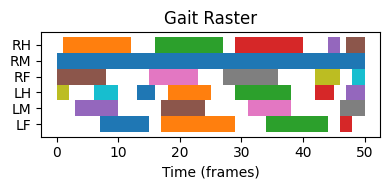

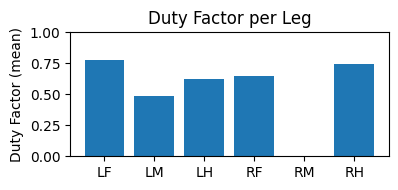

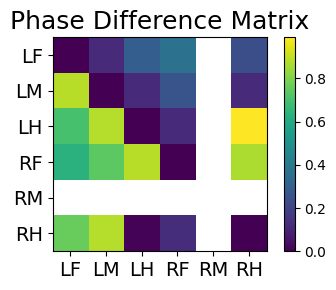

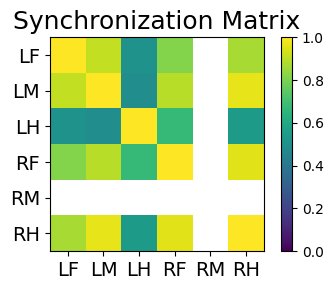

[gait_quant_from_foot_z] Tripod index (footz) = 0.56


In [3]:
tripod_index, df_summary, phase_diff_mat_df, sync_mat_df= gait_quant_from_foot_z(foot_trajs, forces, start, end, use_foot_trajs=True, save_prefix="footz")

In [4]:
df_summary

,leg,duty_mean,duty_std,n_cycles
0,LF,0.779739,0.066097,3
1,LM,0.488889,0.019245,3
2,LH,0.620020,0.046517,5
3,RF,0.644444,0.038490,3
4,RM,NaN,NaN,0
5,RH,0.744872,0.074477,4


In [5]:
phase_diff_mat_df

,LF,LM,LH,RF,RM,RH
LF,0.000000,0.116503,0.297041,0.367493,NaN,0.239412
LM,0.883497,0.000000,0.121083,0.258782,NaN,0.119667
LH,0.702959,0.878917,0.000000,0.116699,NaN,0.990134
RF,0.632507,0.741218,0.883301,0.000000,NaN,0.868952
RM,NaN,NaN,NaN,NaN,NaN,NaN
RH,0.760588,0.880333,0.009866,0.131048,NaN,0.000000


In [6]:
sync_mat_df

,LF,LM,LH,RF,RM,RH
LF,1.000000,0.906917,0.509970,0.812852,NaN,0.867675
LM,0.906917,1.000000,0.489028,0.892346,NaN,0.963634
LH,0.509970,0.489028,1.000000,0.669323,NaN,0.545648
RF,0.812852,0.892346,0.669323,1.000000,NaN,0.953541
RM,NaN,NaN,NaN,NaN,NaN,NaN
RH,0.867675,0.963634,0.545648,0.953541,NaN,1.000000
